Alex Hamilton <br>
MTEOR 227 <br>
Exam #4 <br>
Due Date: 12/16/2022 <br><br>

##################################################################### <br><br>

This program takes in a latitude and longitude that is within the <br>
United States and returns the last two days of observations and the <br>
NWS forecast for the next seven days. It plots the temperature, wind <br>
speed and direction, and forecasted precipitation type. The program <br>
does this in a single plot using matplotlib. To get the data, the <br>
program uses the National Weather Service's API to retrieve it.<br>

<b>Variables:</b><br>
lat: The user-given latitude of the forecast point.<br>
lon: The user-given longitude of the forecast point.<br>
------------------------<br>
api_urlPoints: The API URL that contains point metadata. <br>
responsePoints: The text response for the point. <br>
dataPoints: The JSON text that contains the metadata about the point. <br>
cityName: The name of the closest city to the point. <br>
stateAbbr: The abbreviation of the state the point is in. <br>
cwaPoint: The WFO responsible for this point. <br>
gridXpoint: The NWS the United States into grids. This is the x-value for the point.<br>
gridYpoint: And this is the y-value of the point. <br>
------------------------<br>
api_urlForecast: The API URL that contains the hourly forecast. <br>
responseForecast: The text response with the forecast.<br>
dataForecast: The JSON text that contains all of the forecast data. <br>
dataForecastPeriods: This JSON text is just the hourly forecasts. <br>
------------------------<br>
api_urlStations: The API URL that contains the list of stations near the point. <br>
responseStations: The text response for the list of stations. <br>
dataStations: The JSON text that contains the nearby stations. <br>
stationID: The four letter ID for the nearest station. <br>
------------------------<br>
api_urlStationHist: The API URL that contains the observational data for the station. <br>
responseHist: The text response with the observations. <br>
dataStationHist: The JSON text containing the station's observations. <br>
------------------------<br>
listOfStartTimes: This list contains the timestamps for the forecast periods. <br>
listOfTempsForecast: This list contains all of the temperatures in the forecast. <br>
listOfWindsForecast: This list contains all of the forecasted wind speeds. <br>
listOfWindsDirection: This list contains all of the forecasted wind directions as strings.<br>
listOfNights: If the forecast period is at 'night' (00Z - 12Z), the value in this list is false. <br>
listOfPrecip: This list contains the precip type as a color. Used for plotting precip type. <br>
------------------------<br>
listOfHistTemps: This list contains the observed temperatures at the station. <br>
listOfHistWinds: This list contains the observed wind speeds. <br>
listOfHistDirs: This list contains the observed wind directions. <br>
listOfHistTimes: This list contains the observation timestamps. <br>
------------------------<br>
tempsUpperBound: This is the max value of the forecast temperatures, plus five. For plotting.<br>
tempsLowerBound This is the min value of the forecast temperatures, minus five. For plotting.<br>
------------------------<br>
newTimestampFore: This list contains all of the forecast timestamps parsed into datetimes. <br>
newTimestampHist: This list contains all of the observation timestamps parsed into datetimes. <br>
dateInitial: This is the datetime set as January 1, 1970. <br>
dateCurrent: This is the datetime for the current time. <br>
dateOffset: Some plot elements do not accept datetimes, so a numerical equivalent is needed. <br>
------------------------<br>
listOfWindXandYFore: This list contains all of the x and y components for forecast winds. <br>
listOfWindXandYHist: This list contains all of the x and y components for observed winds. <br>
listOfNewDirect: Due to how the NWS does forecast wind directions, the directions need to be modified.<br>
windLetterDirections: The reference list containing all of the wind letter combinations. <br>
windAngleDirections: This list corresponds directly to the letter list. Contains values in radians. <br>
------------------------<br>
fig, ax: The figure and axes of the plot.
rectCurrent: The rectangle plotted to represent the current time. <br>
dateOffsetRect: An offset needed for plotting the night rectangles. <br>
rect: The rectangles that represent night on the forecast section of the plot. <br>
rectPrecip: These rectangles represent precipitation types in the forecast. <br>
timestampStored: This is the timestamp of the most recent wind barb. Changed multiple times.<br><br>
<b>Inputs</b><br>
lat (<i>float</i>), lon (<i>float</i>)<br><br>
<b>Outputs</b><br>
fig (<i>figure</i>)

Import the modules necessary for the program.

In [4]:
import requests
import json
import numpy as np
import dateutil as du
import datetime
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from metpy.plots import StationPlot
from metpy.units import units

Prompt the user for the latitude and longitude of the point they want forecasted. <br>
It is easier to restart kernel and run all cells, however, it works perfectly fine cell-by-cell.

In [5]:
lat = float(input("Enter the latitude of the city (e.g. 42.00):"))
lon = float(input("Enter the longitude of the city (e.g. -93.62):"))

# Longitude is never positive within the United States.
if(lon > 0): lon *= -1

Requests and extracts data about the given point. These are necessary for later steps.

In [6]:
api_urlPoints = "https://api.weather.gov/points/" + str(lat) + "," + str(lon)
responsePoints = requests.get(api_urlPoints)

# In event that there is an error in retrieving the data from the API, try again. 
# NWS API can have random errors not associated with this program.
if(responsePoints.status_code != 200):
    responsePoints = requests.get(api_urlPoints)

# Checks response status code. If it is not successful, returns an error message with the status.
if(responsePoints.status_code == 200):
    # Load the web response into a JSON data structure.
    dataPoints = json.loads(json.dumps(responsePoints.json()))

    # This collects the city name, state abbreviation, CWA, and x and y grid compo
    cityName = dataPoints['properties']['relativeLocation']['properties']['city']
    stateAbbr = dataPoints['properties']['relativeLocation']['properties']['state']
    cwaPoint = dataPoints['properties']['cwa']
    gridXpoint = dataPoints['properties']['gridX']
    gridYpoint = dataPoints['properties']['gridY']
else:
    print("The URL returned an error code of " + str(responsePoints.status_code) + ", meaning it encountered an issue.")

Requests the seven day forecast from the NWS using the gridpoints from the previous cell.<br>
Fixes potential gridpoint error with NWS grid determining.

In [7]:
api_urlForecast = "https://api.weather.gov/gridpoints/" + cwaPoint + "/" + str(gridXpoint) + "," + str(gridYpoint) +"/forecast/hourly"
responseForecast = requests.get(api_urlForecast)

# Fixes known error with API of certain offices returning out-of-bounds gridpoints. NWS mentions this as a fix.
# Subtract one from each of the gridpoints, then re-request for the data.
if(responseForecast.status_code == 500):
    gridXpoint -= 1
    gridYpoint -= 1
    api_urlForecast = "https://api.weather.gov/gridpoints/" + cwaPoint + "/" + str(gridXpoint) + "," + str(gridYpoint) +"/forecast/hourly"
    responseForecast = requests.get(api_urlForecast)

# In event that there is an error in retrieving the data from the API, try again. 
if(responseForecast.status_code != 200):
    responseForecast = requests.get(api_urlForecast)

# Checks response status code. If it is not successful, returns an error message with the status.
if(responseForecast.status_code == 200):
    # Load the web response into a JSON data structure.
    dataForecast = json.loads(json.dumps(responseForecast.json()))

    # Extracts just the actual forecast periods from the forecast.
    dataForecastPeriods = dataForecast['properties']['periods']
else:
    print("The URL returned an error code of " + str(responseForecast.status_code) + ", meaning it encountered an issue.")

Gets the station identifier nearest to the given point and stores it.

In [8]:
api_urlStations = "https://api.weather.gov/gridpoints/" + cwaPoint + "/" + str(gridXpoint) + "," + str(gridYpoint) + "/stations"
responseStations = requests.get(api_urlStations)

# In event that there is an error in retrieving the data from the API, try again. 
if(responseStations.status_code != 200):
    responseStations = requests.get(api_urlStations)

# Checks response status code. If it is not successful, returns an error message with the status.
if(responseStations.status_code == 200):
    # Load the web response into a JSON data structure.
    dataStations = json.loads(json.dumps(responseStations.json()))

    # Finds the station ID to allow for recent history conditions to be loaded.
    stationID = dataStations['features'][0]['properties']['stationIdentifier']
else:
    print("The URL returned an error code of " + str(responseStations.status_code) + ", meaning it encountered an issue.")

This pulls the actual data from the closest weather station and stores it as JSON.

In [9]:
api_urlStationHist = "https://api.weather.gov/stations/" + stationID + "/observations"
responseHist = requests.get(api_urlStationHist)

# In event that there is an error in retrieving the data from the API, try again. 
if(responseHist.status_code != 200):
    responseHist = requests.get(api_urlStationHist)

# Checks response status code. If it is not successful, returns an error message with the status.
if(responseHist.status_code == 200):
    # Load the web response into a JSON data structure.
    dataStationHist = json.loads(json.dumps(responseHist.json()))
else:
    print("The URL returned an error code of " + str(responseHist.status_code) + ", meaning it encountered an issue.")

Create new lists containing data from the forecast periods to make processing easier.

In [10]:
listOfStartTimes = []
listOfTempsForecast = []
listOfWindsForecast = []
listOfWindsDirection = []
listOfNights = []
listOfPrecip = []

# This section crawls through the list of forecast periods and takes out relevant information.
for i in dataForecastPeriods:
    # For some of these, it is as easy as grabbing the data directly from the JSON file.
    listOfStartTimes.append(i['startTime'])
    listOfTempsForecast.append(i['temperature'])
    # Wind data is returned as a string with letters (e.g. "15 mph"). This extracts the numbers and turns them to ints.
    listOfWindsForecast.append(int(i['windSpeed'][0] + i['windSpeed'][1]))
    listOfWindsDirection.append(i['windDirection'])
    listOfNights.append(i['isDaytime'])
    
    # Determine the precip type, and add the color corresponding to the type to its list.
    # If no precipitation is found in this forecast period, set the color to none.
    if("Rain And Snow" in i['shortForecast']):
        listOfPrecip.append('pink')
    elif("Freezing Rain" in i['shortForecast']):
        listOfPrecip.append('purple')
    elif("Showers And Thunderstorms" in i['shortForecast']):
        listOfPrecip.append('darkorange')
    elif("Thunderstorms" in i['shortForecast']):
        listOfPrecip.append('r')
    elif("Rain" in i['shortForecast']):
        listOfPrecip.append('g')
    elif("Snow" in i['shortForecast']):
        listOfPrecip.append('c')
    else:
        listOfPrecip.append('none')

Grab the wanted data from the observation's JSON response and correct for some known issues.

In [11]:
listOfHistTemps = []
listOfHistWinds = []
listOfHistDirs = []
listOfHistTimes = []

# This loop grabs the relevant data from the historical data's JSON response..
count = 0
for i in dataStationHist['features']:
    
    # Handles if temperature is equal to null in the JSON response.
    if(i['properties']['temperature']['value'] == None):
        initTemp = -999
    else:
        initTemp = i['properties']['temperature']['value']

    # Handles if windspeed or direction is equal to null in the JSON response.
    if(i['properties']['windSpeed']['value'] == None):
        initWind = 0
        initDirection = 0
    elif(i['properties']['windDirection']['value'] == None):
        initWind = i['properties']['windSpeed']['value']
        initDirection = 0
    else:
        initWind = i['properties']['windSpeed']['value']
        initDirection = i['properties']['windDirection']['value']
    
    # After checking if the temperature or wind are null, append the value determined above to their lists.
    listOfHistTemps.append(initTemp)
    listOfHistWinds.append(initWind)
    listOfHistDirs.append(initDirection)
    # Append the timestamps to another list.
    listOfHistTimes.append(i['properties']['timestamp'])

# Initializes the unit for each and then converts them to the correct unit.
listOfHistTemps = listOfHistTemps[:] * units('degC')
listOfHistTemps = listOfHistTemps.to('degF')
listOfHistWinds = listOfHistWinds[:] * units('km/h')
listOfHistWinds = listOfHistWinds.to('kts')
listOfHistDirs = listOfHistDirs[:] * units('deg')
listOfHistDirs = listOfHistDirs.to('rad')

Find the upper and lower bounds of the forecasted temperatures and add an offset.<br>
This allows space on the graph for other items to be plotted.

In [12]:
# The upper and lower bounds are used to give enough clearance on the plot for the precip type boxes and the wind barbs.
# Five is a good compromise between the space needed and making the plot clear across a wide range of temperatures.
tempsLowerBound = min(listOfTempsForecast) - 5
tempsUpperBound = max(listOfTempsForecast) + 5

Gets the timestamps from both the forecasted and observational data. <br>
Also finds the date offset, which is necessary for some elements of plotting correctly.

In [13]:
# Parses put the timestamps into a more usable format.
newTimestampFore = [du.parser.parse(x) for x in listOfStartTimes]
newTimestampHist = [du.parser.parse(x) for x in listOfHistTimes]

# This is used to calculate the offset that has to be applied to the rectangles to allow them to be charted.
# Outputs the time in days since January 1, 1970 which is the date from which datetime calculates for the numeric equivalent.
dateInitial = datetime.datetime(1970,1,1,0,0)
dateCurrent = datetime.datetime.now()
dateOffset = (dateCurrent - dateInitial).total_seconds()/86400

Finds the x and y components of the winds for observations and forecasts.<br>
The forecasted winds are not in the ideal format for finding x and y, so this has to be <br>
converted into radians, which NumPy's trig functions accept.

In [14]:
listOfWindXandYFore = []
listOfWindXandYHist = []
listOfNewDirect = []
# Since the NWS returns forecasted wind directions as a set of letters, there needs to be a conversion into numerical values.
# 'N' corresponds to 0, 'S' corresponds to pi.
windLetterDirections = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
windAngleDirections = [0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2, 5*np.pi/8, 3*np.pi/4, 7*np.pi/8, np.pi, \
                       9*np.pi/8, 5*np.pi/4, 11*np.pi/8, 3*np.pi/2, 13*np.pi/8, 7*np.pi/4, 15*np.pi/8]

# This loop calculates the x and y wind components of the forecasted data...
count1 = 0
for i in listOfWindsDirection:
    # This finds the item in the wind angles that corresponds with the 1 to 3 letter wind forecast.
    listOfNewDirect.append(windAngleDirections[windLetterDirections.index(listOfWindsDirection[count1])])
    
    # This calculates the components of the wind (x and y), which is necessary for MetPy's wind barbs.
    listOfWindXandYFore.append(((-listOfWindsForecast[count1]*np.sin(listOfNewDirect[count1])), \
                                (-listOfWindsForecast[count1]*np.cos(listOfNewDirect[count1]))))
    count1 += 1

# ...while this loop calculates the x and y components of the historical wind data.
count2 = 0
for j in listOfHistWinds:
    # This calculates and appends the x and y compentents of the historic winds for the MetPy barbs.
    listOfWindXandYHist.append(((-listOfHistWinds[count2]*np.sin(listOfHistDirs[count2])), \
                                (-listOfHistWinds[count2]*np.cos(listOfHistDirs[count2]))))
    count2 += 1

<u>Finally, plots all of the data above into one matplotlib plot. </u> <br>
First, it directly plots the observed and forecasted temperatures. <br>
Then, it adds a line representing the current time. <br>
This then adds boxes representing nighttime and precip type for the forecast. <br>
After that, this then plots wind barbs for the observations and forecasts at 6 hour intervals. <br>
Lastly, it adjusts and names the axes, adds clarifying text, and formats dates.

<>:63: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\c'
C:\Users\alexh\AppData\Local\Temp\ipykernel_12976\2140897407.py:63: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Temperature ($^\circ$F)')


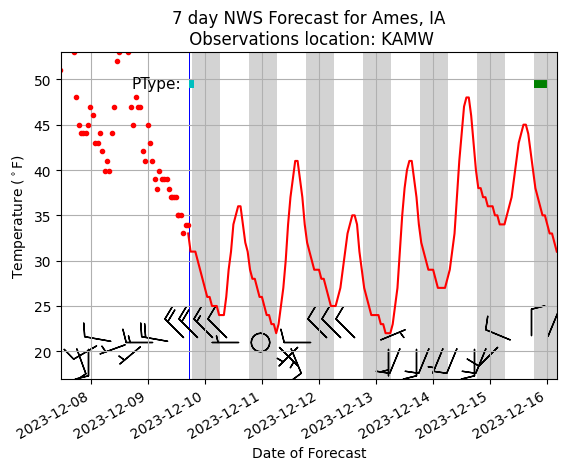

In [15]:
fig, ax = plt.subplots()

# Plot the historical and forecasted temperatures onto the graph.
ax.plot(newTimestampFore, listOfTempsForecast, 'r')
ax.plot(newTimestampHist, listOfHistTemps, 'r.')

# This adds a line to the plot starting at the current time to show where the transition is from obs to forecast.
rectCurrent = patches.Rectangle((dateOffset + (6/24), -100), (1/48), 300, facecolor='blue')
ax.add_patch(rectCurrent)

# This draws the boxes for nighttime on the forecasted section of the plot.
# Whether or not it is considered night is not available from the station observations.
count1 = 0
for i in dataForecastPeriods:
    # The rectangle does not accept a datetime as a coordinate, so it has to be converted.
    # dateOffset is the initial offset, in days since 1970. The current index has to be divided by 24 since it represents hours.
    # The final addition of 6/24 accounts for the shift in time zones. Assumes Central.
    dateOffsetRect = dateOffset + (count1 / 24) + (6/24)
    
    # Draws dark boxes on the plot hour by hour to signify nighttime.
    if(listOfNights[count1] == False):
        rect = patches.Rectangle((dateOffsetRect, -100), (1/24), 300, facecolor='lightgray')
        ax.add_patch(rect)

    # Adds rectangles to chart showing if precipitation is falling during the period and which type if so.
    rectPrecip = patches.Rectangle((dateOffsetRect, tempsUpperBound-4), (1/24), 1.0, facecolor=str(listOfPrecip[count1]))
    ax.add_patch(rectPrecip)
    
    count1 += 1
    
# The wind barbs need to be graphed after the night boxes, otherwise they tend to get covered up.
count2 = 0
for j in dataForecastPeriods:
    # Plots a wind barb every 6 units, which is equivalent to every 6 hours.
    if(count2 % 6 == 0):
        stationplot = StationPlot(ax, newTimestampFore[count2], tempsLowerBound + 4, clip_on=True)
        stationplot.plot_barb(listOfWindXandYFore[count2][0], listOfWindXandYFore[count2][1])
    count2 += 1

# This section plots the historical wind data for the last few days.
count3 = 0
# The timestamp is initialized to allow comparison. This allows the program to only plot the wind barbs every six hours.
# This is needed since stations do not observe at the same intervals, meaning the barbs would otherwise be closer
# or farther apart, depending on the station.
timestampStored = newTimestampHist[0]
for k in listOfHistWinds:
    # If the difference in time since the last plotted barb is greater than six hours (21,600 seconds), plot a wind barb.
    if((timestampStored - newTimestampHist[count3]).total_seconds() >= 21600):
        stationplot = StationPlot(ax, newTimestampHist[count3], tempsLowerBound + 4, clip_on=True)
        stationplot.plot_barb(listOfWindXandYHist[count3][0], listOfWindXandYHist[count3][1])
        
        # Reset the timestamp for comparison.
        timestampStored = newTimestampHist[count3]
    count3 += 1

# The bounds of the plot are set as 2 days before now and the ending timestamp, and the upper and lower temp bounds.
# The lower and upper bounds are the temperature mins and maxs, with a constant offset.
plt.axis([dateOffset - 2,newTimestampFore[len(newTimestampFore) - 1],tempsLowerBound,tempsUpperBound])

# Set the title and axes labels.
ax.set_title('7 day NWS Forecast for ' + cityName + ", " + stateAbbr + "\n Observations location: " + stationID)
ax.set_xlabel('Date of Forecast')
ax.set_ylabel('Temperature ($^\circ$F)')

# This places the PType text on the graphic in the right place at the right size.
text_kwargs = dict(ha='center', va='center', fontsize=11)
plt.text(float(dateOffset)-(8/24), tempsUpperBound-3.5, 'PType:', **text_kwargs)

# Enable the grid on the plot.
ax.grid(True)

# Automatically format the dates to make them look much nicer.
fig.autofmt_xdate()

# Show the plot.
plt.show()